# Build a `Scene`: `Background`

A scene is a composition of three elements:
- A pointsource (`target`)
- A continuum flat background  (`background`)
- A structured background (`host`).

`slicersim.Scene` takes as input these three elements, but they could be left as _None_, resulting to a corresponding null spectrum (np.zeros).

**In that example, we will build a flat background: zodiacal light**

***
## A Background : Zodiacal

A Background needs only element:
- a `model_func`, any function that takes as input `lbda` and returns `flux`

For simplicity, we have built-in several zodialcal light models.


In [1]:
from slicersim.scene import background

In [2]:
from slicersim.scene import background
model_func = background.get_background_model_func("zodi")
model_func

<function slicersim.scene.background.zodiacal_spectrum(lbda, scale=1, model='Aldering01.BB5800')>

In [3]:
bkgd = background.Background(model_func)

In [4]:
import numpy as np
lbda = np.linspace(3_300, 17_000, 500)

In [5]:
lbda, flux = bkgd.get_spectrum(lbda)

Text(0, 0.5, 'flux [erg/s/cm^2/A]')

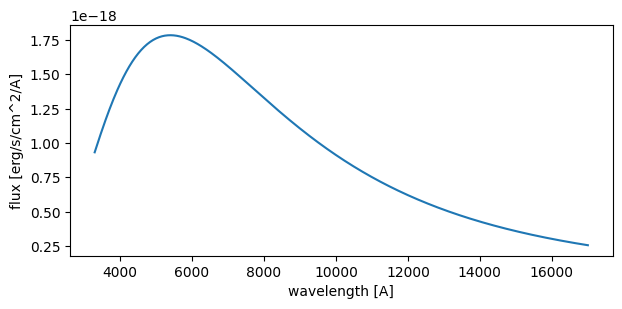

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=[7,3])
ax.plot(lbda, flux)
ax.set_xlabel("wavelength [A]")
ax.set_ylabel("flux [erg/s/cm^2/A]")

## update any parameters you want

In [7]:
bkgd.mutable_parameters

['lbda', 'scale', 'model']

let's change the model from "Aldering01.BB5800" (default) to "Aldering01.TPL" (see model_func docstring)

In [8]:
bkgd.update(model="Aldering01.TPL")

the target metadata are now updated as will as the model

In [9]:
bkgd.meta

{'model': 'Aldering01.TPL'}

In [10]:
up_lbda, up_flux = bkgd.get_spectrum(lbda)

Text(0, 0.5, 'flux [erg/s/cm^2/A]')

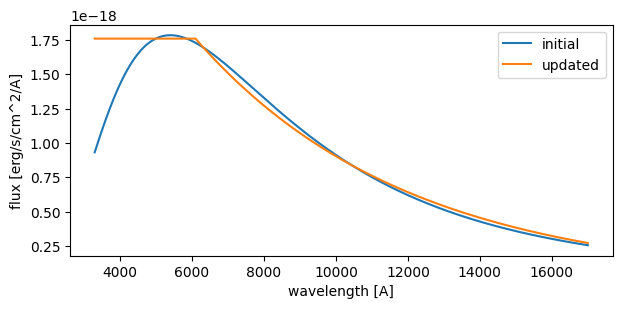

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=[7,3])
ax.plot(lbda, flux, label="initial")
ax.plot(up_lbda, up_flux, label="updated")

ax.legend()
ax.set_xlabel("wavelength [A]")
ax.set_ylabel("flux [erg/s/cm^2/A]")

# Load Supernovae from a config file

You may want to set the model and position parameters in a config dictionary. 

Just use the `.from_config()` to load a supernovae instance from this configuration

In [12]:
from slicersim import iotools
bkgd_config = iotools.get_config()["scene"]["background"]
bkgd_config

{'name': 'zodi', 'model': 'Aldering01.BB5800', 'scale': 2.0}

In [13]:
bkgd = background.Background.from_config(bkgd_config) # a name is required to find the model_func

In [14]:
lbda, flux = bkgd.get_spectrum(lbda)

Text(0, 0.5, 'flux [erg/s/cm^2/A]')

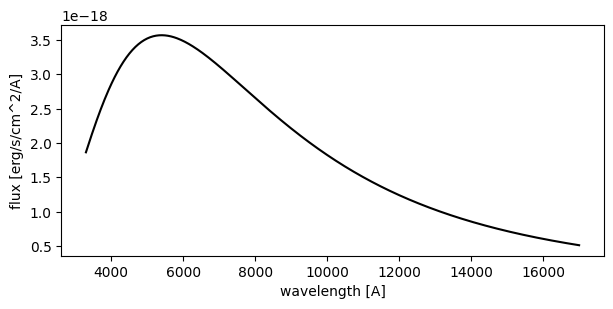

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=[7,3])
ax.plot(lbda, flux, label="initial", color="k")
ax.set_xlabel("wavelength [A]")
ax.set_ylabel("flux [erg/s/cm^2/A]")

# Link with `Spectrograph`

In practice the lbda is given by the spectrograph. In the code that is simply done as follows

In [16]:
import slicersim

In [17]:
spectro_config = iotools.get_config()["spectrograph"]
spectrograph = slicersim.Spectrograph.from_config(spectro_config)

In [18]:
lbda, flux = bkgd.get_spectrum(spectrograph.lbda)

Text(0.5, 1.0, 'Supernovae at spectrograph resolution')

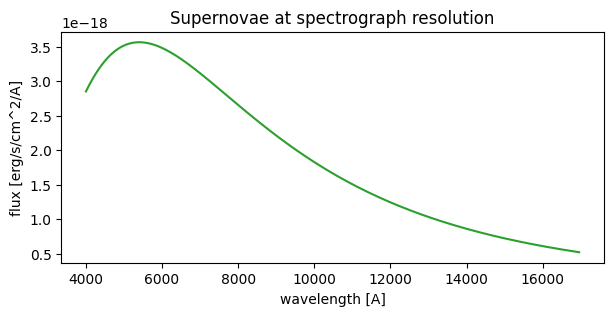

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=[7,3])
ax.plot(lbda, flux, label="initial", color="tab:green")
ax.set_xlabel("wavelength [A]")
ax.set_ylabel("flux [erg/s/cm^2/A]")
ax.set_title("Supernovae at spectrograph resolution")